# Registered ERA5 temperature pilot

This notebook evaluates issue #5 and protocol v0.2. The coordinate-complete
sample contains failures but no susceptible-slope denominator. Ranks are
reanalysis exposure diagnostics, not estimates of failure odds or attribution.
The original seven-day window is retained; a time-basis audit added a uniform
one-day-buffered sensitivity before those new values were read.

In [1]:
from pathlib import Path
import json, matplotlib.pyplot as plt, numpy as np, pandas as pd
root=Path.cwd(); data=root/'data'/'reanalysis'; figures=root/'figures'
d=pd.read_csv(data/'diagnostics.csv', float_precision='round_trip')
cells=pd.read_csv(data/'event_cells.csv', float_precision='round_trip')
air=pd.read_csv(data/'above_freezing_sensitivity.csv', float_precision='round_trip')
manifest=json.loads((data/'retrieval_manifest.json').read_text()); p=d[d.primary_cell].copy()
print('Snapshot:',manifest['icechunk_snapshot'],'; coverage:',manifest['time_coverage_start'],'to',manifest['time_coverage_end'])
print('Coordinate-complete sample: 29/53 trigger-time-eligible occurrences')

Snapshot: T9H8SG2PVXWNY0QNJPJG ; coverage: 1940-01-01T00:00:00Z to 2026-03-31T23:00:00Z
Coordinate-complete sample: 29/53 trigger-time-eligible occurrences


## Registered windows and fitted-linear-trend sensitivity

Warm-state ranks use matched 1991--2020 calendar windows. Linear-trend-residual
ranks remove one Theil--Sen line over 1979--2025; nonlinear secular change,
low-frequency variability, and reanalysis inhomogeneity can remain.

,median warm-state rank,median linear-trend-residual rank,warm rank > 0.5,linear-residual rank > 0.5
window,,,,
2d,0.551724,0.448276,15,14
7d,0.586207,0.482759,19,14
7d_buffered,0.586207,0.533333,21,16
30d,0.724138,0.655172,17,17
event_day,0.533333,0.448276,15,14


7d IQR warm/residual (0.379, 0.828) (0.267, 0.828) ; 25-component medians 0.586 0.533
7d_buffered IQR warm/residual (0.483, 0.8) (0.3, 0.759) ; 25-component medians 0.621 0.552


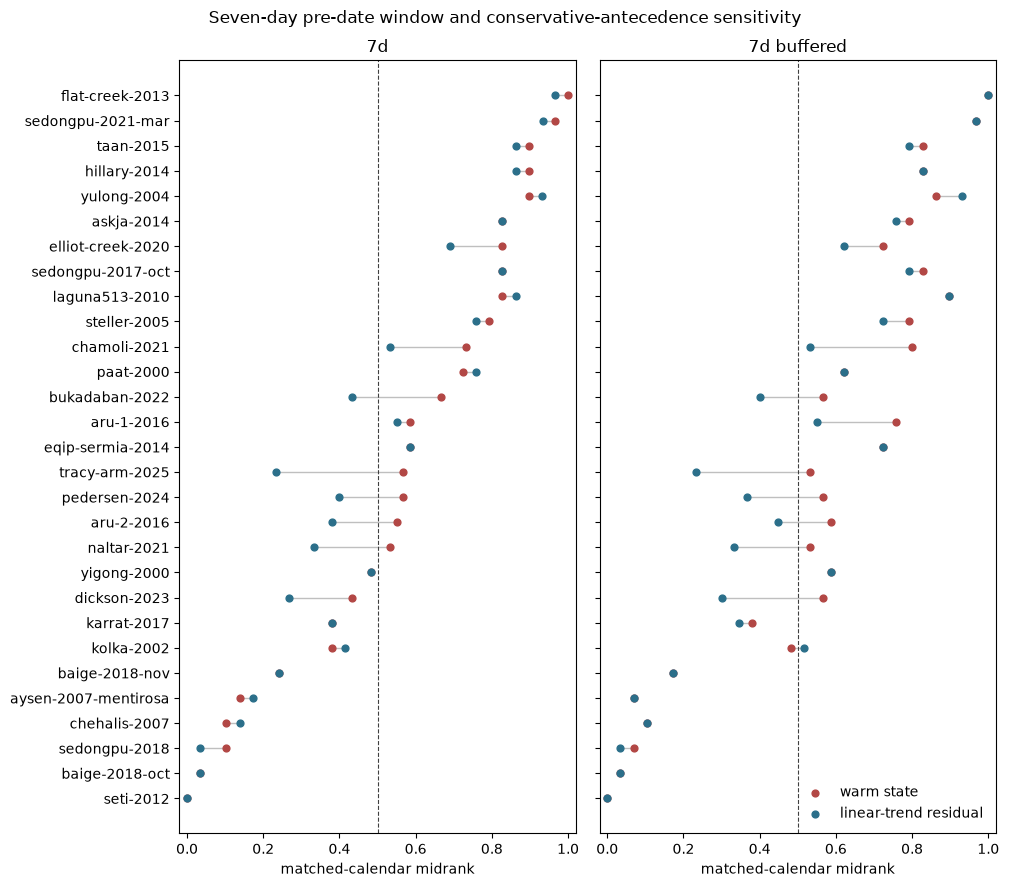

In [2]:
order=['2d','7d','7d_buffered','30d','event_day']; g=p.groupby('window')
summary=g[['warm_state_rank','linear_trend_residual_rank']].median().loc[order]
summary['warm rank > 0.5']=g.warm_state_rank.apply(lambda x:(x>.5).sum()).loc[order]
summary['linear-residual rank > 0.5']=g.linear_trend_residual_rank.apply(lambda x:(x>.5).sum()).loc[order]
display(summary.rename(columns={'warm_state_rank':'median warm-state rank','linear_trend_residual_rank':'median linear-trend-residual rank'}))
for window in ['7d','7d_buffered']:
    q=p[p.window==window]; reps=q[q.component_representative]
    print(window,'IQR warm/residual',tuple(q.warm_state_rank.quantile([.25,.75]).round(3)),tuple(q.linear_trend_residual_rank.quantile([.25,.75]).round(3)),'; 25-component medians',round(reps.warm_state_rank.median(),3),round(reps.linear_trend_residual_rank.median(),3))
names=p[p.window=='7d'].sort_values('warm_state_rank').candidate_id.tolist(); fig,axes=plt.subplots(1,2,figsize=(10.2,9),sharey=True)
for ax,window in zip(axes,['7d','7d_buffered']):
    q=p[p.window==window].set_index('candidate_id').loc[names].reset_index(); y=np.arange(len(q))
    for i,row in q.iterrows(): ax.plot([row.warm_state_rank,row.linear_trend_residual_rank],[i,i],color='.75',lw=1)
    ax.scatter(q.warm_state_rank,y,s=24,label='warm state',color='#b24745',zorder=3); ax.scatter(q.linear_trend_residual_rank,y,s=24,label='linear-trend residual',color='#2b6f8a',zorder=3)
    ax.axvline(.5,color='.25',lw=.8,ls='--'); ax.set(xlim=(-.02,1.02),xlabel='matched-calendar midrank',title=window.replace('_',' ')); ax.set_yticks(y)
axes[0].set_yticklabels(names); axes[1].tick_params(labelleft=False); axes[1].legend(frameon=False,loc='lower right')
fig.suptitle('Seven-day pre-date window and conservative-antecedence sensitivity'); fig.tight_layout(); fig.savefig(figures/'era5_pilot_ranks.pdf'); fig.savefig(figures/'era5_pilot_ranks.png',dpi=180); plt.show()

## Grid and elevation sensitivity

The left panel retains every registered cell. The right panel shows lapse-
adjusted ERA5 2-m air-temperature hours above 273.15 K; it does not measure or
imply rock, soil, or ice thaw. Elevation offsets are scenarios, not estimates.

,rank_span,height_span_m
window,,
7d,0.133333,323.23645
7d_buffered,0.103448,323.23645


site_minus_model_height_km          -1      0     1    2
window      lapse_rate_k_per_km                         
7d          4.0                  160.0  113.0  42.0  0.0
            6.5                  168.0  113.0  11.0  0.0
            9.0                  168.0  113.0   0.0  0.0
7d_buffered 4.0                  158.0  121.0  50.0  0.0
            6.5                  168.0  121.0  11.0  0.0
            9.0                  168.0  121.0   0.0  0.0

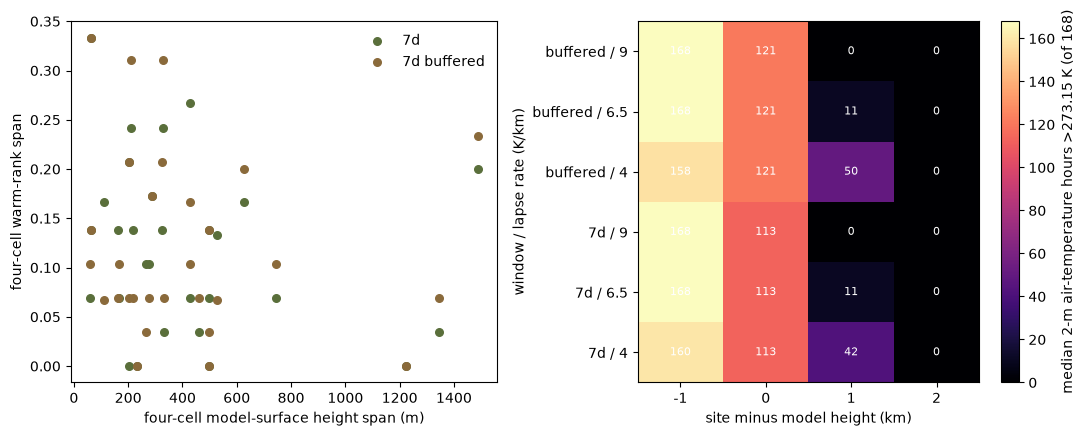

In [3]:
four=d[d.window.isin(['7d','7d_buffered'])].groupby(['candidate_id','window']).warm_state_rank.agg(['min','max']); four['rank_span']=four['max']-four['min']
h=cells.groupby('candidate_id').model_surface_height_m.agg(['min','max']); h['height_span_m']=h['max']-h['min']; four=four.join(h.height_span_m)
matrix=air.groupby(['window','lapse_rate_k_per_km','site_minus_model_height_km']).hours_above_273_15_k.median().unstack(); display(four.groupby('window')[['rank_span','height_span_m']].median()); display(matrix)
fig,axes=plt.subplots(1,2,figsize=(11,4.4))
for window,color in [('7d','#5a6f3b'),('7d_buffered','#8a6a3b')]:
    q=four.xs(window,level='window'); axes[0].scatter(q.height_span_m,q.rank_span,s=30,label=window.replace('_',' '),color=color)
axes[0].set(xlabel='four-cell model-surface height span (m)',ylabel='four-cell warm-rank span'); axes[0].legend(frameon=False)
image=axes[1].imshow(matrix.values,origin='lower',aspect='auto',cmap='magma',vmin=0,vmax=168); labels=[f'{w.replace("7d_buffered","buffered")} / {r:g}' for w,r in matrix.index]
axes[1].set(xticks=range(len(matrix.columns)),xticklabels=matrix.columns,yticks=range(len(labels)),yticklabels=labels,xlabel='site minus model height (km)',ylabel='window / lapse rate (K/km)')
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]): axes[1].text(j,i,f'{matrix.iloc[i,j]:.0f}',ha='center',va='center',color='white',fontsize=8)
fig.colorbar(image,ax=axes[1],label='median 2-m air-temperature hours >273.15 K (of 168)'); fig.tight_layout(); fig.savefig(figures/'era5_pilot_sensitivity.pdf'); fig.savefig(figures/'era5_pilot_sensitivity.png',dpi=180); plt.show()

## Bounded reading

Central ranks vary with window definition and fitted-trend adjustment, and
neighboring cells and elevation scenarios materially alter absolute exposure.
The coordinate-complete subset is discovery-source selective. These results
motivate verified onset times, terrain downscaling, and a non-event denominator;
they do not support a climate-trigger or hazard-frequency claim.